In [1]:
from idun_guardian_sdk import GuardianClient, FileTypes
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [12]:
my_api_token = "idun_MWSQ4pkewAGNz8wwYzw_NsweXihLC8tIcFzah8vqqys4Nc-ALzjfTwl2"
my_recording_id = "1776156319749"

if __name__ == "__main__":
   client = GuardianClient(api_token=my_api_token)
   client.download_file(recording_id=my_recording_id, file_type=FileTypes.EEG)


   client.get_recording_reports(my_recording_id)

[INFO] 2026-04-20 19:27:45,074: [API]: File saved: 'eeg_1776156319749.csv'
[INFO] 2026-04-20 19:27:45,074: [API]: File saved: 'eeg_1776156319749.csv'
[INFO] 2026-04-20 19:27:45,074: [API]: File saved: 'eeg_1776156319749.csv'


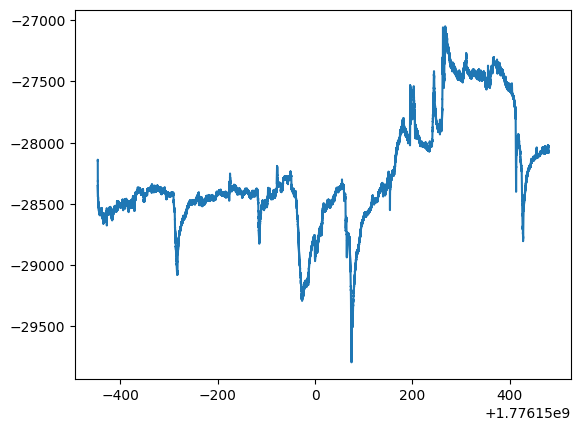

In [2]:
data = pd.read_csv('eeg_Simon_3.csv')
dt = np.median(np.diff(data['timestamp']))
fs = 1 / dt
plt.plot(data['timestamp'], data['ch1'])

In [3]:
sos_notch = signal.iirdesign(
  wp=[46, 54], ws=[48, 52],
  gpass=1, gstop=60,
  ftype="cheby2", output="sos", fs=fs)

sos_hp = signal.iirdesign(
  wp=1, ws=0.5, 
  gpass=1, gstop=40,
  analog=False, ftype="butter", output="sos", fs=fs)
   
data_filt = signal.sosfilt(sos_notch, data['ch1'])
data_filt = signal.sosfilt(sos_hp, data_filt)
cut_samples = 2000
data_filt = data_filt[cut_samples:]
time_filt = data['timestamp'].to_numpy()[cut_samples:]

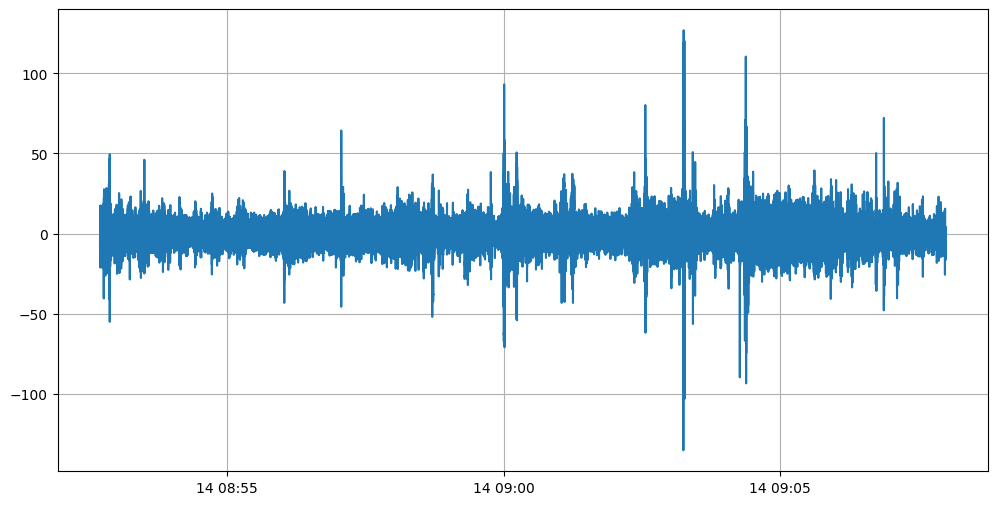

In [4]:
time_dt = pd.to_datetime(data['timestamp'], unit='s').dt.tz_localize('UTC').dt.tz_convert('Europe/Zurich')
plt.figure(figsize=(12, 6))
plt.plot(time_dt[2000:], data_filt)
plt.grid()

In [5]:
def epoch_signal(x, fs, epoch_sec=2.0):
   L = int(epoch_sec * fs)
   n_epochs = len(x) // L
   x = x[:n_epochs * L]
   return x.reshape(n_epochs, L)
epoch_sec = 2.0

def mad(a):
   med = np.median(a)
   return np.median(np.abs(a - med)) + 1e-12

epochs = epoch_signal(data_filt, fs, epoch_sec=2.0)

# metrics per epoch
ptp = np.ptp(epochs, axis=1)
rms = np.sqrt(np.mean(epochs**2, axis=1))
dmax = np.max(np.abs(np.diff(epochs, axis=1)), axis=1)

# robust thresholds: median + k*MAD
def robust_thresh(v, k=6.0):
   return np.median(v) + k * mad(v)

ptp_th = robust_thresh(ptp, k=6)
rms_th = robust_thresh(rms, k=6)
dmax_th = robust_thresh(dmax, k=6)

good = (ptp < ptp_th) & (rms < rms_th) & (dmax < dmax_th)

epochs_good = epochs[good]
good_idx = np.where(good)[0]
print(f"Kept {good.mean()*100:.1f}% of epochs ({good.sum()}/{len(good)})")

Kept 90.6% of epochs (415/458)


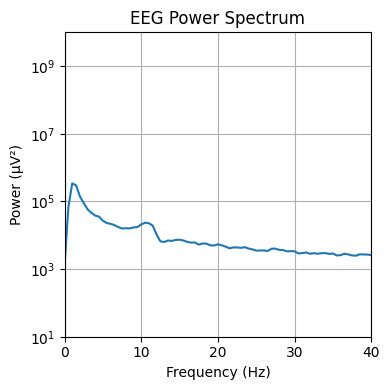

In [6]:
# FFT per epoch and average power\n",
P = []
for e in epochs_good:
   E = np.fft.rfft(e * np.hanning(len(e)))
   P.append(np.abs(E)**2)

P_mean = np.mean(P, axis=0)
freqs = np.fft.rfftfreq(len(epochs_good[0]), d=1/fs)


# FFT per epoch and average power using scipy.signal.welch
P_welch = []
for e in epochs_good:
   freqs_welch, E_welch = signal.welch(e, fs=fs, nperseg=len(e))
   P_welch.append(np.abs(E_welch)**2)

P_mean_welch = np.mean(P_welch, axis=0)

plt.figure(figsize=(4, 4))
plt.plot(freqs, P_mean)
plt.xlim(0, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (µV²)")
plt.yscale('log')
plt.ylim(1e1, 1e10)
plt.title("EEG Power Spectrum")
plt.tight_layout()
plt.grid()
plt.show()

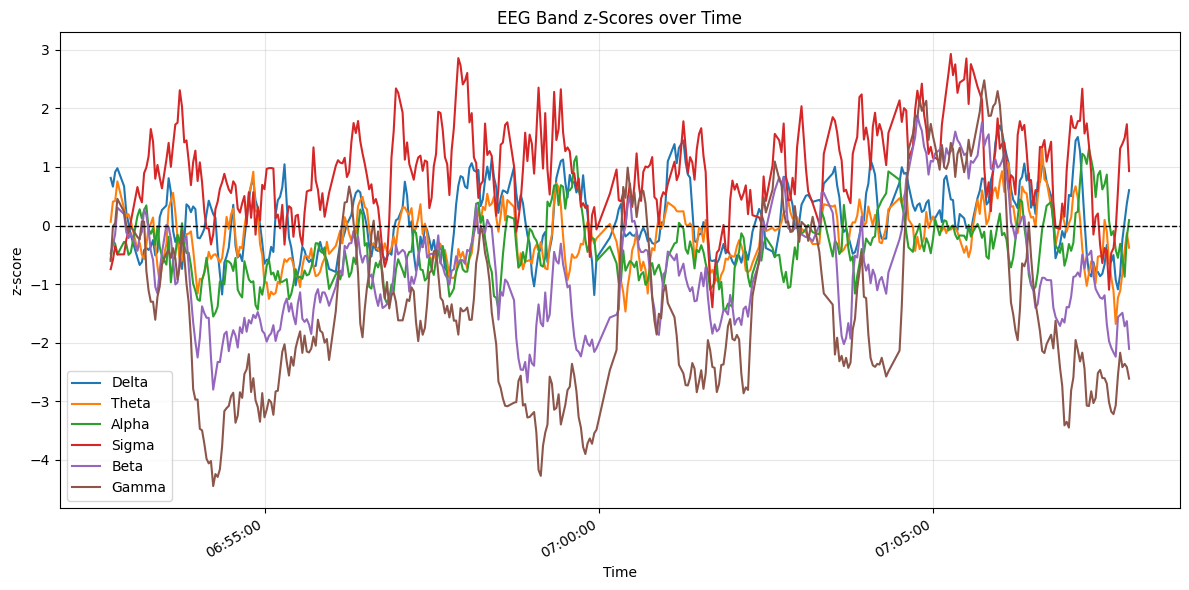

In [7]:
def bandpower(freqs, psd, fmin, fmax):
    idx = (freqs >= fmin) & (freqs < fmax)
    if not np.any(idx):
        return np.nan
    return np.trapezoid(psd[idx], freqs[idx])

bands = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 12),
    "Sigma": (12, 15),
    "Beta":  (13, 30),
    "Gamma": (30, 35),
}

bandpowers = []

for e in epochs_good:
    f, pxx = signal.welch(
        e,
        fs=fs,
        window="hann",
        nperseg=len(e),
        noverlap=len(e)//2,
        detrend="constant",
        scaling="density"
    )

    bp = {band: bandpower(f, pxx, lo, hi) for band, (lo, hi) in bands.items()}
    bandpowers.append(bp)

df_bp = pd.DataFrame(bandpowers)

# =========================================
# z-Scores berechnen
# =========================================
# log-transform macht die Verteilung stabiler
df_log = np.log(df_bp + 1e-12)

# Baseline: erste 10 gute Epochen
n_baseline = min(10, len(df_log))
baseline = df_log.iloc[:n_baseline]

mu = baseline.mean()
sigma = baseline.std().replace(0, 1e-12)

z_scores = (df_log - mu) / sigma

# Optional glätten
z_smooth = z_scores.rolling(window=5, min_periods=1).mean()

# =========================================
# Zeitachse für die guten Epochen
# =========================================
start_time = pd.to_datetime(time_filt[0], unit='s')
epoch_times = start_time + pd.to_timedelta(good_idx * epoch_sec, unit='s')

z_smooth["time"] = epoch_times

# =========================================
# z-Score-Kurven plotten
# =========================================
plt.figure(figsize=(12, 6))

for band in bands:
    plt.plot(z_smooth["time"], z_smooth[band], label=band, linewidth=1.5)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Time")
plt.ylabel("z-score")
plt.title("EEG Band z-Scores over Time")
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

In [8]:
def band_power(freqs, power, fmin, fmax):
   idx = np.logical_and(freqs >= fmin, freqs < fmax)
   df = freqs[1] - freqs[0]
   return np.sum(power[idx]) * df

delta = band_power(freqs, P_mean, 0.5, 4)
theta = band_power(freqs, P_mean, 4, 8)
alpha = band_power(freqs, P_mean, 8, 12)
sigma = band_power(freqs, P_mean, 12, 15)
beta  = band_power(freqs, P_mean, 13, 30)
gamma = band_power(freqs, P_mean, 30, 35)

total = delta + theta + alpha + beta

print("Relative power:")
print(f"Delta: {delta/total:.2%}")
print(f"Theta: {theta/total:.2%}")
print(f"Alpha: {alpha/total:.2%}")
print(f"Sigma: {sigma/total:.2%}")
print(f"Beta:  {beta/total:.2%}")
print(f"Gamma: {gamma/total:.2%}")

Relative power:
Delta: 66.79%
Theta: 12.70%
Alpha: 9.78%
Sigma: 2.85%
Beta:  10.73%
Gamma: 1.90%


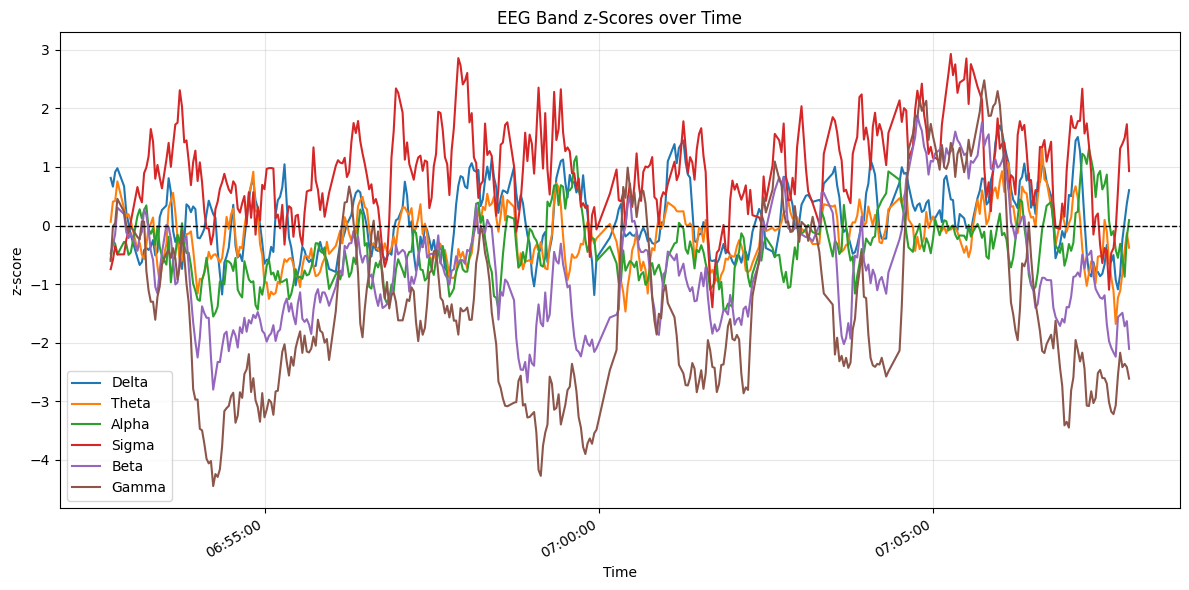

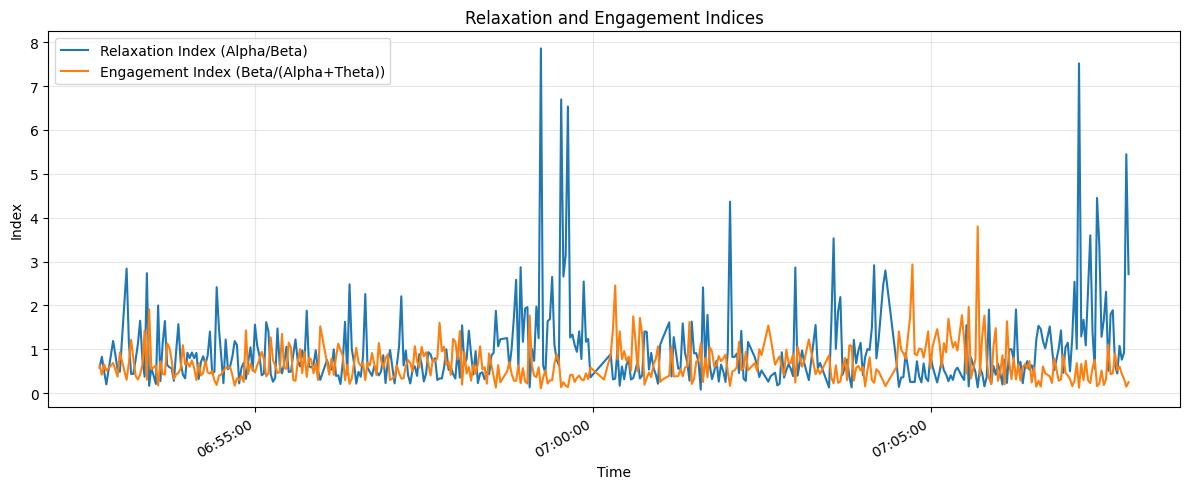

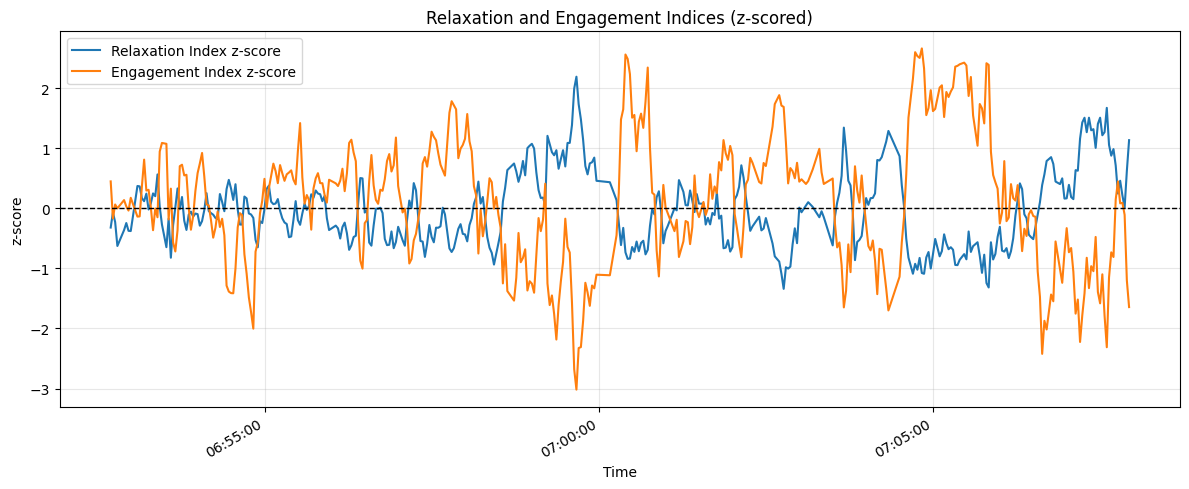

                           time     Alpha      Beta      Theta  \
0 2026-04-14 06:52:41.890000105  2.029454  3.480550   3.441334   
1 2026-04-14 06:52:43.890000105  3.183106  3.830140   5.865821   
2 2026-04-14 06:52:45.890000105  2.211311  4.458516   4.613622   
3 2026-04-14 06:52:47.890000105  1.488719  7.341816  12.777295   
4 2026-04-14 06:52:53.890000105  4.478966  3.757415   0.979308   

   Relaxation_Index  Engagement_Index  
0          0.583084          0.636206  
1          0.831068          0.423270  
2          0.495975          0.653269  
3          0.202773          0.514637  
4          1.192034          0.688389  


In [9]:
def bandpower(freqs, psd, fmin, fmax):
    idx = (freqs >= fmin) & (freqs < fmax)
    if not np.any(idx):
        return np.nan
    return np.trapezoid(psd[idx], freqs[idx])

bands = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 12),
    "Sigma": (12, 15),
    "Beta":  (13, 30),
    "Gamma": (30, 35),
}

bandpowers = []

for e in epochs_good:
    f, pxx = signal.welch(
        e,
        fs=fs,
        window="hann",
        nperseg=len(e),
        noverlap=len(e)//2,
        detrend="constant",
        scaling="density"
    )

    bp = {band: bandpower(f, pxx, lo, hi) for band, (lo, hi) in bands.items()}
    bandpowers.append(bp)

df_bp = pd.DataFrame(bandpowers)

# =========================================
# Indizes berechnen
# =========================================
eps = 1e-12

# Relaxationsindikator: Alpha / Beta
df_bp["Relaxation_Index"] = df_bp["Alpha"] / (df_bp["Beta"] + eps)

# Engagement Index: Beta / (Alpha + Theta)
df_bp["Engagement_Index"] = df_bp["Beta"] / (df_bp["Alpha"] + df_bp["Theta"] + eps)

# Optional: log-transformierte Varianten für stabilere Darstellung
df_bp["log_Relaxation_Index"] = np.log(df_bp["Relaxation_Index"] + eps)
df_bp["log_Engagement_Index"] = np.log(df_bp["Engagement_Index"] + eps)

# =========================================
# z-Scores berechnen
# =========================================
# log-transform macht die Verteilung stabiler
df_log = np.log(df_bp[["Delta", "Theta", "Alpha", "Sigma", "Beta", "Gamma"]] + eps)

# Baseline: erste 10 gute Epochen
n_baseline = min(10, len(df_log))
baseline = df_log.iloc[:n_baseline]

mu = baseline.mean()
sigma = baseline.std().replace(0, 1e-12)

z_scores = (df_log - mu) / sigma
z_smooth = z_scores.rolling(window=5, min_periods=1).mean()

# =========================================
# Optional: z-Scores der Indizes
# =========================================
df_idx_log = np.log(df_bp[["Relaxation_Index", "Engagement_Index"]] + eps)

baseline_idx = df_idx_log.iloc[:n_baseline]
mu_idx = baseline_idx.mean()
sigma_idx = baseline_idx.std().replace(0, 1e-12)

z_idx = (df_idx_log - mu_idx) / sigma_idx
z_idx_smooth = z_idx.rolling(window=5, min_periods=1).mean()

# =========================================
# Zeitachse für die guten Epochen
# =========================================
start_time = pd.to_datetime(time_filt[0], unit='s')
epoch_times = start_time + pd.to_timedelta(good_idx * epoch_sec, unit='s')

z_smooth["time"] = epoch_times
z_idx_smooth["time"] = epoch_times
df_bp["time"] = epoch_times

# =========================================
# z-Score-Kurven der Bänder plotten
# =========================================
plt.figure(figsize=(12, 6))

for band in bands:
    plt.plot(z_smooth["time"], z_smooth[band], label=band, linewidth=1.5)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Time")
plt.ylabel("z-score")
plt.title("EEG Band z-Scores over Time")
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

# =========================================
# Indizes plotten (absolute Werte)
# =========================================
plt.figure(figsize=(12, 5))
plt.plot(df_bp["time"], df_bp["Relaxation_Index"], label="Relaxation Index (Alpha/Beta)")
plt.plot(df_bp["time"], df_bp["Engagement_Index"], label="Engagement Index (Beta/(Alpha+Theta))")
plt.xlabel("Time")
plt.ylabel("Index")
plt.title("Relaxation and Engagement Indices")
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

# =========================================
# Indizes plotten (z-transformiert)
# =========================================
plt.figure(figsize=(12, 5))
plt.plot(z_idx_smooth["time"], z_idx_smooth["Relaxation_Index"], label="Relaxation Index z-score")
plt.plot(z_idx_smooth["time"], z_idx_smooth["Engagement_Index"], label="Engagement Index z-score")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Time")
plt.ylabel("z-score")
plt.title("Relaxation and Engagement Indices (z-scored)")
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

# Optional: kurzer Überblick
print(df_bp[["time", "Alpha", "Beta", "Theta", "Relaxation_Index", "Engagement_Index"]].head())